In [19]:
# Библиотеки были установлены в занятии 1.
# Если этот ноутбук запускается первым — раскомментируйте следующую строку:
# %pip install opencv-python matplotlib numpy

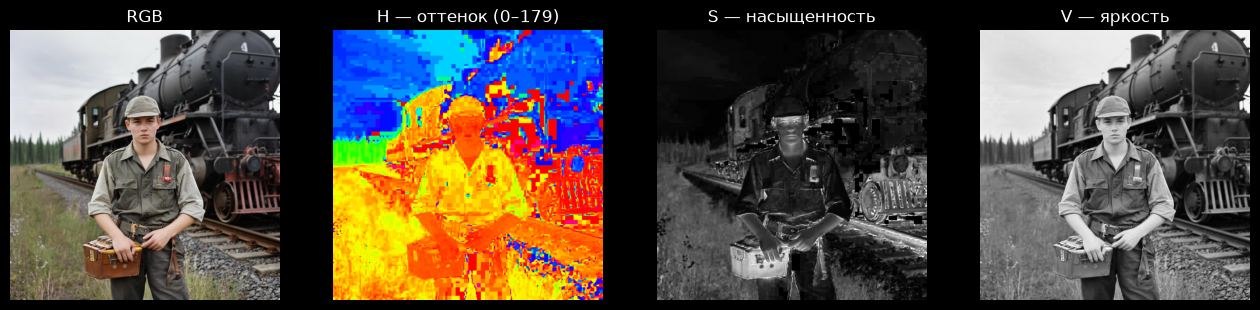

In [20]:
# Работа с цветовыми пространствами

import cv2
import matplotlib.pyplot as plt

img = cv2.imread("example.jpg")

# RGB — для отображения
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# HSV — для анализа цвета: H (оттенок), S (насыщенность), V (яркость)
img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

fig, ax = plt.subplots(1, 4, figsize=(16, 4))
ax[0].imshow(img_rgb);                       ax[0].set_title("RGB")
ax[1].imshow(img_hsv[:, :, 0], cmap="hsv"); ax[1].set_title("H — оттенок (0–179)")
ax[2].imshow(img_hsv[:, :, 1], cmap="gray"); ax[2].set_title("S — насыщенность")
ax[3].imshow(img_hsv[:, :, 2], cmap="gray"); ax[3].set_title("V — яркость")
for a in ax:
    a.axis("off")
plt.show()

In [21]:
# Числовые значения канала Hue (оттенок).
#
# ВАЖНО: в теории оттенок измеряется в градусах 0–360°,
# но OpenCV хранит Hue в диапазоне 0–179 (градусы делятся пополам,
# чтобы уместиться в байт uint8). Поэтому, например, «красный» — это
# пороги около 0 и около 179, а не 0–360. Частая ошибка новичков!

print("Диапазон Hue в этом изображении:", img_hsv[:, :, 0].min(), "—", img_hsv[:, :, 0].max())
print()
print("Фрагмент матрицы Hue (пиксели 5×5 из левого верхнего угла):")
print(img_hsv[:5, :5, 0])

Диапазон Hue в этом изображении: 0 — 179

Фрагмент матрицы Hue (пиксели 5×5 из левого верхнего угла):
[[116 116 116 116 116]
 [116 116 116 116 116]
 [116 116 116 116 116]
 [116 116 116 116 116]
 [116 116 116 116 116]]


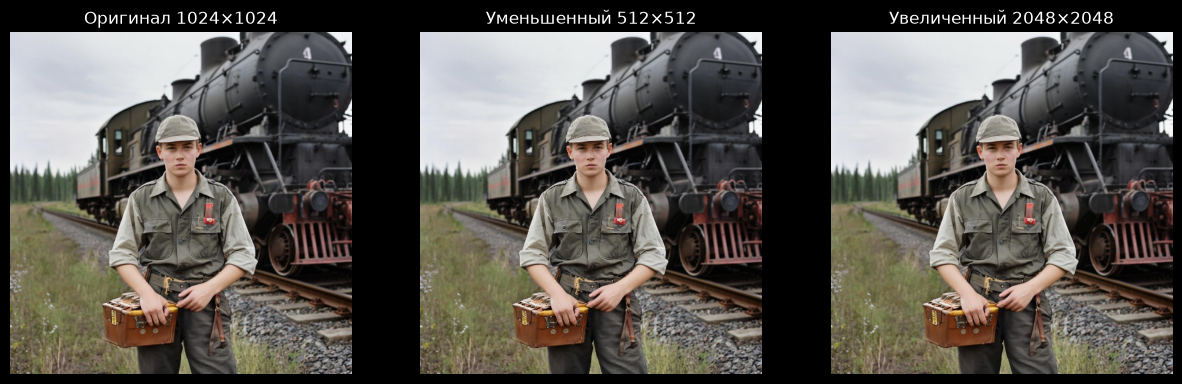

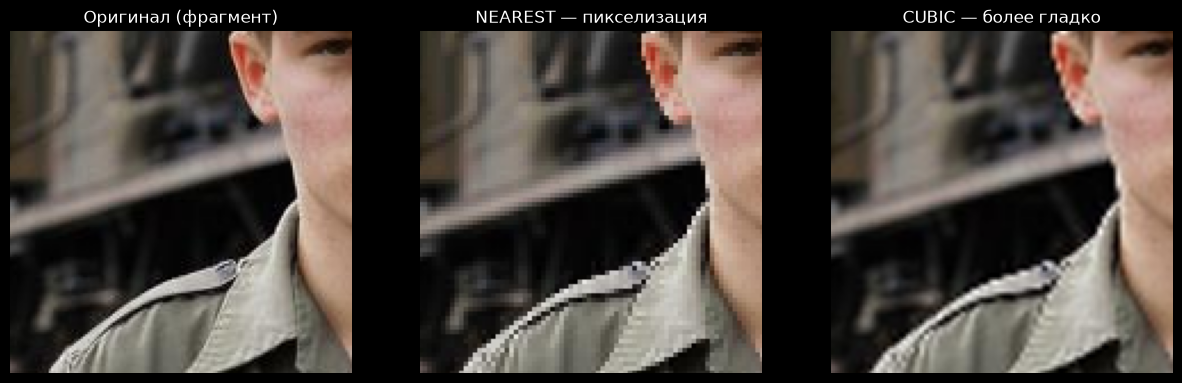

In [22]:
# Масштабирование изображений
#
# ВАЖНО: cv2.resize принимает размер как (ширина, высота),
# а img.shape возвращает (высота, ширина, каналы) — порядок разный!

h, w = img.shape[:2]

# Способ 1: фиксированный размер — (width, height)
resized_small = cv2.resize(img, (w // 2, h // 2), interpolation=cv2.INTER_NEAREST)
resized_big   = cv2.resize(img, (w * 2, h * 2), interpolation=cv2.INTER_CUBIC)

# Способ 2: коэффициенты (в 2 раза меньше / больше — как в индивидуальном задании):
# resized_small = cv2.resize(img, None, fx=0.5, fy=0.5, interpolation=cv2.INTER_NEAREST)
# resized_big   = cv2.resize(img, None, fx=2.0, fy=2.0, interpolation=cv2.INTER_CUBIC)

cv2.imwrite("resized_small.jpg", resized_small)
cv2.imwrite("resized_big.jpg", resized_big)

def to_rgb(im):
    return cv2.cvtColor(im, cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(to_rgb(img));           ax[0].set_title(f"Оригинал {w}×{h}")
ax[1].imshow(to_rgb(resized_small)); ax[1].set_title(f"Уменьшенный {w//2}×{h//2}")
ax[2].imshow(to_rgb(resized_big));   ax[2].set_title(f"Увеличенный {w*2}×{h*2}")
for a in ax:
    a.axis("off")
plt.show()

# Сравнение интерполяции: уменьшили → снова увеличили, смотрим один и тот же фрагмент
restored_nearest = cv2.resize(to_rgb(resized_small), (w, h), interpolation=cv2.INTER_NEAREST)
restored_cubic   = cv2.resize(to_rgb(resized_small), (w, h), interpolation=cv2.INTER_CUBIC)

y0, x0, frag = h // 3, w // 3, 150  # одинаковый фрагмент у всех трёх
img_rgb = to_rgb(img)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(img_rgb[y0:y0+frag, x0:x0+frag]);         ax[0].set_title("Оригинал (фрагмент)")
ax[1].imshow(restored_nearest[y0:y0+frag, x0:x0+frag]); ax[1].set_title("NEAREST — пикселизация")
ax[2].imshow(restored_cubic[y0:y0+frag, x0:x0+frag]);   ax[2].set_title("CUBIC — более гладко")
for a in ax:
    a.axis("off")
plt.show()

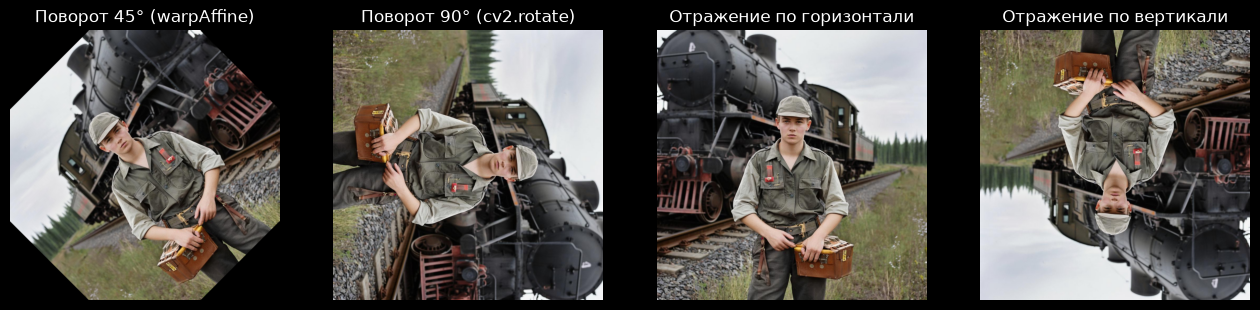

In [23]:
# Поворот и отражение

(h, w) = img.shape[:2]
center = (w // 2, h // 2)

# Поворот на произвольный угол (45°) вокруг центра
M = cv2.getRotationMatrix2D(center, 45, 1.0)
rotated = cv2.warpAffine(img, M, (w, h))

# Для углов, кратных 90°, есть более простой и быстрый способ (без потерь качества):
rotated_90 = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)

# Отражения
flipped_h = cv2.flip(img, 1)   # по горизонтали (зеркало)
flipped_v = cv2.flip(img, 0)   # по вертикали (вверх ногами)

def to_rgb(im):
    return cv2.cvtColor(im, cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(1, 4, figsize=(16, 5))
ax[0].imshow(to_rgb(rotated));    ax[0].set_title("Поворот 45° (warpAffine)")
ax[1].imshow(to_rgb(rotated_90)); ax[1].set_title("Поворот 90° (cv2.rotate)")
ax[2].imshow(to_rgb(flipped_h));  ax[2].set_title("Отражение по горизонтали")
ax[3].imshow(to_rgb(flipped_v));  ax[3].set_title("Отражение по вертикали")
for a in ax:
    a.axis("off")
plt.show()

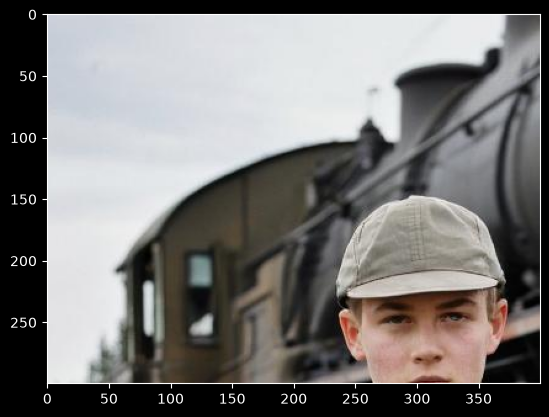

In [24]:
# Обрезка (crop)

cropped = img[100:400, 200:600]  # область по координатам [y1:y2, x1:x2]

plt.imshow(cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB))
plt.show()

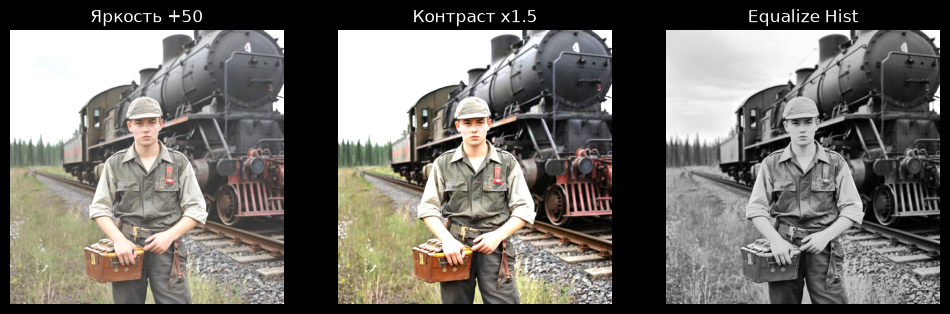

In [25]:
# Работа с яркостью и контрастом

# Увеличение яркости
bright = cv2.convertScaleAbs(img, alpha=1, beta=50)  # beta = смещение яркости

# Увеличение контраста
contrast = cv2.convertScaleAbs(img, alpha=1.5, beta=0)

# Выравнивание гистограммы для grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
equalized = cv2.equalizeHist(gray)

# Отображение
fig, ax = plt.subplots(1, 3, figsize=(12,4))
ax[0].imshow(cv2.cvtColor(bright, cv2.COLOR_BGR2RGB)); ax[0].set_title("Яркость +50"); ax[0].axis("off")
ax[1].imshow(cv2.cvtColor(contrast, cv2.COLOR_BGR2RGB)); ax[1].set_title("Контраст x1.5"); ax[1].axis("off")
ax[2].imshow(equalized, cmap="gray"); ax[2].set_title("Equalize Hist"); ax[2].axis("off")
plt.show()


До:    dtype = uint8 , min–max: 0 – 255
После: dtype = float64 , min–max: 0.0 – 1.0


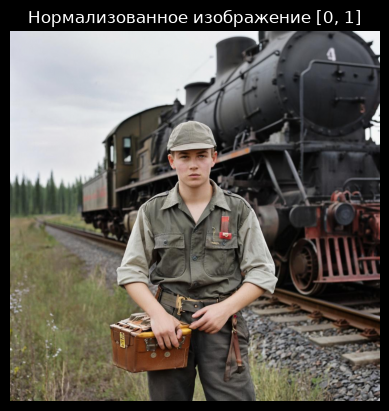

In [26]:
# Нормализация: перевод значений пикселей в диапазон [0, 1]
# Именно в таком виде изображения подают на вход нейросетям (занятия 6–7)

img_norm = img_rgb / 255.0   # uint8 [0..255] → float [0..1]

print("До:    dtype =", img_rgb.dtype, ", min–max:", img_rgb.min(), "–", img_rgb.max())
print("После: dtype =", img_norm.dtype, ", min–max:", round(float(img_norm.min()), 3), "–", round(float(img_norm.max()), 3))

plt.imshow(img_norm)  # выглядит так же — изменились только числа внутри массива
plt.title("Нормализованное изображение [0, 1]")
plt.axis("off")
plt.show()

Индивидуальные задания студентам

Прочитать изображение и отобразить его в RGB, HSV и Grayscale.

Масштабировать изображение в 2 раза меньше и в 2 раза больше, сравнить качество.

Написать функцию, которая поворачивает изображение на 90°.

Вырезать из изображения центральный фрагмент размером 200×200 пикселей.

Увеличить яркость и контраст изображения и сохранить результат.

(Дополнительно) Реализовать свою функцию нормализации:

Привести значения пикселей к диапазону [0,1].

Умножить на коэффициент и обратно привести к [0,255].

## Индивидуальные задания

In [27]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

image_path = "T8_dacha_26_484.jpg"
image = cv2.imread(image_path)

if image is None:
    raise FileNotFoundError(f"Не удалось прочитать файл: {image_path}")

h, w = image.shape[:2]


### Read image


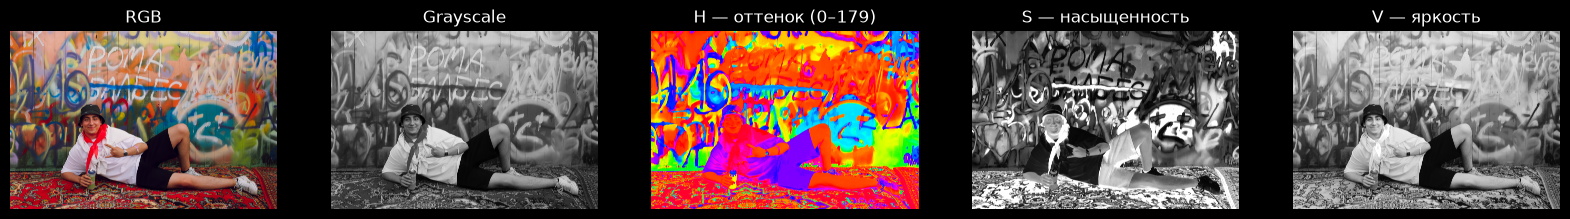

In [28]:
img_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Grayscale — для отображения яркости
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# HSV — для анализа цвета: H (оттенок), S (насыщенность), V (яркость)
img_hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

fig, ax = plt.subplots(1, 5, figsize=(20, 4))
ax[0].imshow(img_rgb);                       ax[0].set_title("RGB")
ax[1].imshow(gray, cmap="gray");             ax[1].set_title("Grayscale")
ax[2].imshow(img_hsv[:, :, 0], cmap="hsv");  ax[2].set_title("H — оттенок (0–179)")
ax[3].imshow(img_hsv[:, :, 1], cmap="gray"); ax[3].set_title("S — насыщенность")
ax[4].imshow(img_hsv[:, :, 2], cmap="gray"); ax[4].set_title("V — яркость")
for a in ax:
    a.axis("off")
plt.show()


### Scale


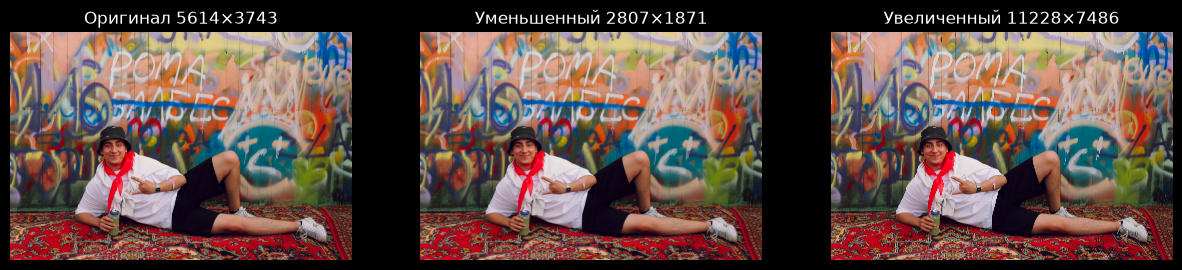

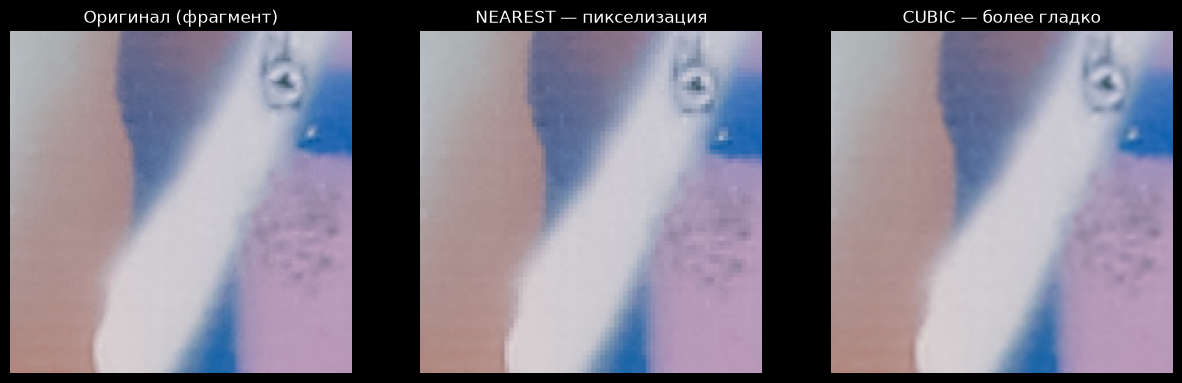

In [29]:
h, w = image.shape[:2]

resized_small = cv2.resize(image, (w // 2, h // 2), interpolation=cv2.INTER_NEAREST)
resized_big   = cv2.resize(image, (w * 2, h * 2), interpolation=cv2.INTER_CUBIC)

def to_rgb(im):
    return cv2.cvtColor(im, cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(to_rgb(image));           ax[0].set_title(f"Оригинал {w}×{h}")
ax[1].imshow(to_rgb(resized_small)); ax[1].set_title(f"Уменьшенный {w//2}×{h//2}")
ax[2].imshow(to_rgb(resized_big));   ax[2].set_title(f"Увеличенный {w*2}×{h*2}")
for a in ax:
    a.axis("off")
plt.show()


restored_nearest = cv2.resize(to_rgb(resized_small), (w, h), interpolation=cv2.INTER_NEAREST)
restored_cubic   = cv2.resize(to_rgb(resized_small), (w, h), interpolation=cv2.INTER_CUBIC)

y0, x0, frag = h // 3, w // 3, 150  # одинаковый фрагмент у всех трёх
img_rgb = to_rgb(image)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(img_rgb[y0:y0+frag, x0:x0+frag]);         ax[0].set_title("Оригинал (фрагмент)")
ax[1].imshow(restored_nearest[y0:y0+frag, x0:x0+frag]); ax[1].set_title("NEAREST — пикселизация")
ax[2].imshow(restored_cubic[y0:y0+frag, x0:x0+frag]);   ax[2].set_title("CUBIC — более гладко")
for a in ax:
    a.axis("off")
plt.show()


### Move image to 90 degrees


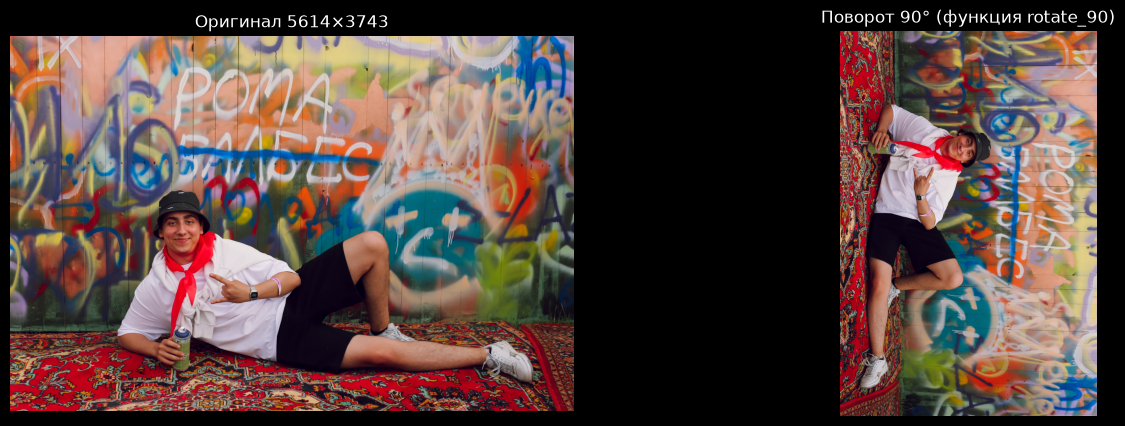

In [30]:
def rotate_90(img):
    """Повернуть изображение на 90° по часовой стрелке."""
    return cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)

rotated_90 = rotate_90(image)

fig, ax = plt.subplots(1, 2, figsize=(16, 5))
ax[0].imshow(to_rgb(image));       ax[0].set_title(f"Оригинал {w}×{h}")
ax[1].imshow(to_rgb(rotated_90));  ax[1].set_title("Поворот 90° (функция rotate_90)")

for a in ax:
    a.axis("off")

plt.show()


### Get image 200x200


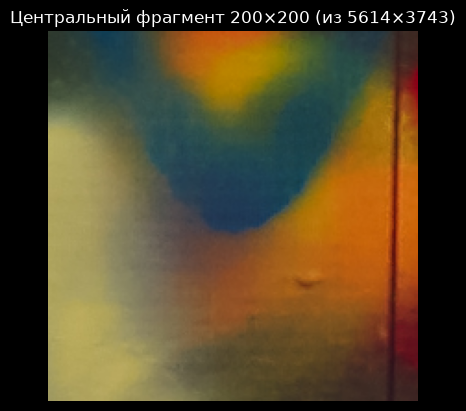

In [31]:
y0 = (h - 200) // 2
x0 = (w - 200) // 2
cropped = image[y0:y0 + 200, x0:x0 + 200]  # центральный фрагмент 200×200

plt.imshow(cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB))
plt.title(f"Центральный фрагмент 200×200 (из {w}×{h})")
plt.axis("off")
plt.show()


### Увеличить яркость и контраст изображения и сохранить результат.


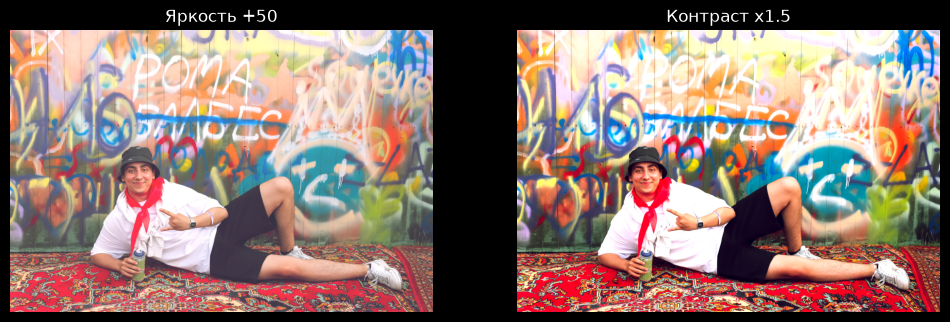

In [32]:
bright = cv2.convertScaleAbs(image, alpha=1, beta=50)  # beta = смещение яркости

# Увеличение контраста
contrast = cv2.convertScaleAbs(image, alpha=1.5, beta=0)

# Отображение
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].imshow(cv2.cvtColor(bright, cv2.COLOR_BGR2RGB)); ax[0].set_title("Яркость +50"); ax[0].axis("off")
ax[1].imshow(cv2.cvtColor(contrast, cv2.COLOR_BGR2RGB)); ax[1].set_title("Контраст x1.5"); ax[1].axis("off")

base = image_path.rsplit(".", 1)[0]
cv2.imwrite(f"{base}_light.jpg", bright)
cv2.imwrite(f"{base}_contrast.jpg", contrast)

plt.show()


### Normalization


### Функции нормализации


Нормализация [0,1]: dtype = float64 , min–max: 0.0 – 1.0


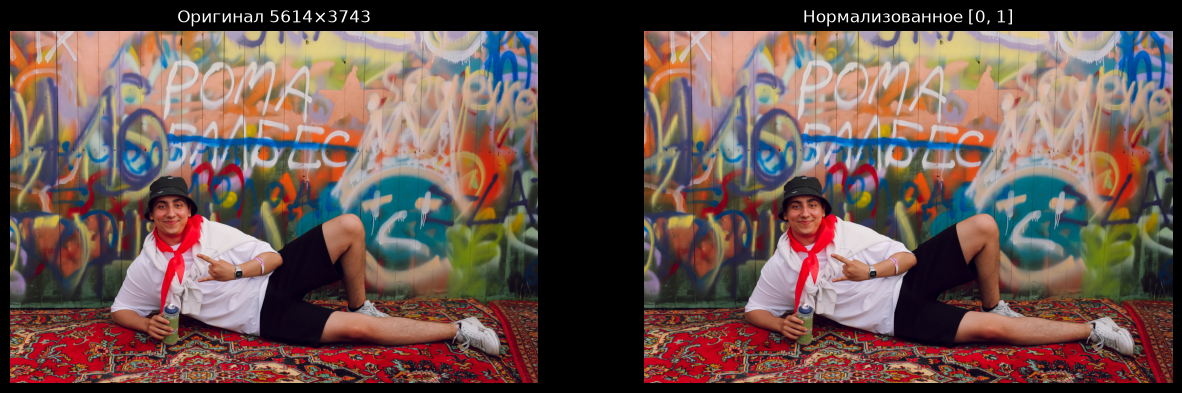

In [33]:
def normalize_to_01(images_trans):
    """Привести значения пикселей к диапазону [0, 1]."""
    return images_trans.astype(np.float64) / 255.0


img_norm = normalize_to_01(img_rgb)
print("Нормализация [0,1]: dtype =", img_norm.dtype,
      ", min–max:", round(float(img_norm.min()), 3), "–", round(float(img_norm.max()), 3))

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].imshow(img_rgb); ax[0].set_title(f"Оригинал {w}×{h}")
ax[1].imshow(img_norm); ax[1].set_title("Нормализованное [0, 1]")
for a in ax:
    a.axis("off")
plt.show()


Обратно [0,255] (коэфф 2.0): dtype = uint8 , min–max: 0 – 255


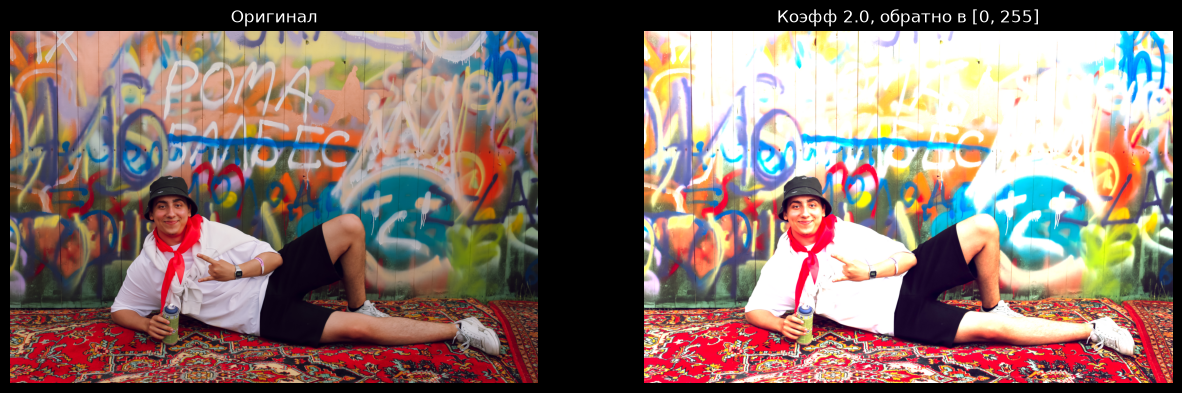

In [34]:
def denormalize_from_01(images_trans, coefficient):
    """Умножить на коэффициент и обратно привести к [0, 255]."""
    img_scaled = images_trans * coefficient
    img_clipped = np.clip(img_scaled, 0, 1)
    return (img_clipped * 255).astype(np.uint8)


# Цепочка: [0, 255] → [0, 1] → умножить на коэффициент → обратно в [0, 255]
img_restored = denormalize_from_01(normalize_to_01(img_rgb), coefficient=2.0)
print("Обратно [0,255] (коэфф 2.0): dtype =", img_restored.dtype,
      ", min–max:", img_restored.min(), "–", img_restored.max())

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].imshow(img_rgb); ax[0].set_title("Оригинал")
ax[1].imshow(img_restored); ax[1].set_title("Коэфф 2.0, обратно в [0, 255]")
for a in ax:
    a.axis("off")
plt.show()
